# Exploratory bidirectional perturbation analysis

This notebook explores the completed donor-held-out Geneformer delete and overexpression results. It ranks genes by a balanced combination of cosine-shift strength and detection coverage, then provides functional labels for the prioritized candidates. These are model-level sensitivity signals, not experimental causal effects.

## TL;DR

The balanced score uses the weaker perturbation arm for both effect size and coverage. This prevents highly detected housekeeping genes with tiny shifts from dominating, while avoiding unstable large shifts supported by only a few cells.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd()
ROOT = Path(os.environ.get('SCLC_PERTURBATION_ROOT', '/home/thinkstation2/workspace/KD/sclc_luad_normal_htan_heldout_allgene_perturbation'))
STATS = ROOT / 'stats'
TABLES = HERE / 'tables'
FIGURES = HERE / 'figures' / 'exploration'
rankings = pd.read_csv(TABLES / 'exploration_balanced_rankings.csv')
functional_summary = pd.read_csv(TABLES / 'exploration_functional_summary.csv')
top_by_comparison = pd.read_csv(TABLES / 'exploration_top_candidates_by_comparison.csv')
rankings.head(10)

,Gene_name,Ensembl_ID,delete_shift,delete_fdr,delete_n,overexpress_shift,overexpress_fdr,overexpress_n,comparison,min_detection,min_abs_shift,mean_abs_shift,detection_norm,shift_norm,balanced_score,functional_category
0,RPS17,ENSG00000182774,-0.009730,0.000000e+00,5767,0.012540,0.000000e+00,5757,luad_to_normal,5757,0.009730,0.011135,0.905046,1.000000,0.951339,Translation / ribosome
1,S100A4,ENSG00000196154,-0.005558,0.000000e+00,5590,0.006906,5.883989e-193,5590,luad_to_normal,5590,0.005558,0.006232,0.878793,1.000000,0.937439,Cytoskeleton / motility
2,RPL41,ENSG00000229117,0.004414,4.816869e-14,6269,-0.019213,0.000000e+00,6269,luad_to_normal,6269,0.004414,0.011814,0.985537,0.801744,0.888903,Translation / ribosome
3,DNAJB1,ENSG00000132002,0.006218,1.792970e-250,5094,-0.012939,0.000000e+00,5004,luad_to_normal,5004,0.006218,0.009578,0.786669,1.000000,0.886943,Stress / proteostasis
4,JUN,ENSG00000177606,0.010666,0.000000e+00,4459,-0.016404,0.000000e+00,4453,luad_to_normal,4453,0.010666,0.013535,0.700047,1.000000,0.836688,Signaling / transcription
5,RPL27A,ENSG00000166441,-0.009197,0.000000e+00,6161,0.003912,1.677132e-42,6161,luad_to_normal,6161,0.003912,0.006554,0.968558,0.710500,0.829555,Translation / ribosome
6,ZNF90,ENSG00000213988,0.015846,0.000000e+00,4451,-0.024486,0.000000e+00,4369,luad_to_normal,4369,0.015846,0.020166,0.686842,1.000000,0.828759,Other / unannotated here
7,HLA-C,ENSG00000204525,0.003842,2.522511e-153,6243,-0.019057,0.000000e+00,6242,luad_to_normal,6242,0.003842,0.011449,0.981292,0.697828,0.827510,Antigen presentation / immune
8,S100A10,ENSG00000197747,-0.004908,3.765863e-224,4861,0.020796,0.000000e+00,4861,luad_to_normal,4861,0.004908,0.012852,0.764188,0.891479,0.825383,Cytoskeleton / motility
9,HSPA8,ENSG00000109971,0.004193,2.053445e-151,5540,-0.012797,0.000000e+00,5536,luad_to_normal,5536,0.004193,0.008495,0.870303,0.761601,0.814140,Stress / proteostasis


## Methods and quality checks

A candidate must be significant in both arms (`FDR < 0.05`), have opposite-signed shifts, and have at least 25 detections in each arm. `min_abs_shift` is the smaller absolute shift across the two arms; `min_detection` is the smaller detection count. Both are normalized within each comparison, with shift values capped at the 95th percentile. The final score is `sqrt(normalized_detection * normalized_shift)`.

In [2]:
assert rankings['balanced_score'].between(0, 1).all()
assert (rankings['min_detection'] >= 25).all()
assert (rankings['delete_shift'] * rankings['overexpress_shift'] < 0).all()
print('Qualified comparison rows:', len(rankings))
print('Unique genes:', rankings['Ensembl_ID'].nunique())
rankings.groupby('comparison').size().rename('qualified_rows').to_frame()

Qualified comparison rows: 3586
Unique genes: 1889


,qualified_rows
comparison,
luad_to_normal,1243
luad_to_sclc,1239
normal_to_luad,155
normal_to_sclc,252
sclc_to_luad,413
sclc_to_normal,284


## Balanced ranking

Use `comparison` to focus on one disease transition. The table below shows the highest-ranked candidates overall; the saved CSV contains all qualified rows.

In [3]:
rankings.sort_values(['balanced_score', 'min_detection'], ascending=False)[['comparison', 'Gene_name', 'delete_shift', 'overexpress_shift', 'min_abs_shift', 'min_detection', 'balanced_score']].head(30)

,comparison,Gene_name,delete_shift,overexpress_shift,min_abs_shift,min_detection,balanced_score
1243,luad_to_sclc,B2M,0.007852,-0.008787,0.007852,6384,1.000000
3302,sclc_to_normal,B2M,0.005340,-0.005078,0.005078,2420,1.000000
2889,sclc_to_luad,HLA-C,0.021159,-0.079266,0.021159,2405,0.996896
3303,sclc_to_normal,HLA-C,-0.004390,0.015168,0.004390,2405,0.996896
2637,normal_to_sclc,HLA-C,-0.006439,0.034442,0.006439,553,0.989324
1244,luad_to_sclc,HLA-C,-0.014972,0.053189,0.014972,6242,0.988816
2638,normal_to_sclc,RPS17,0.008929,-0.004744,0.004744,531,0.969445
0,luad_to_normal,RPS17,-0.009730,0.012540,0.009730,5757,0.951339
1245,luad_to_sclc,RPS17,0.020615,-0.013385,0.013385,5757,0.949624
1,luad_to_normal,S100A4,-0.005558,0.006906,0.005558,5590,0.937439


## Figures

The scatter plot shows the two objectives directly. Point size encodes the balanced score; labels identify the overall top candidates.

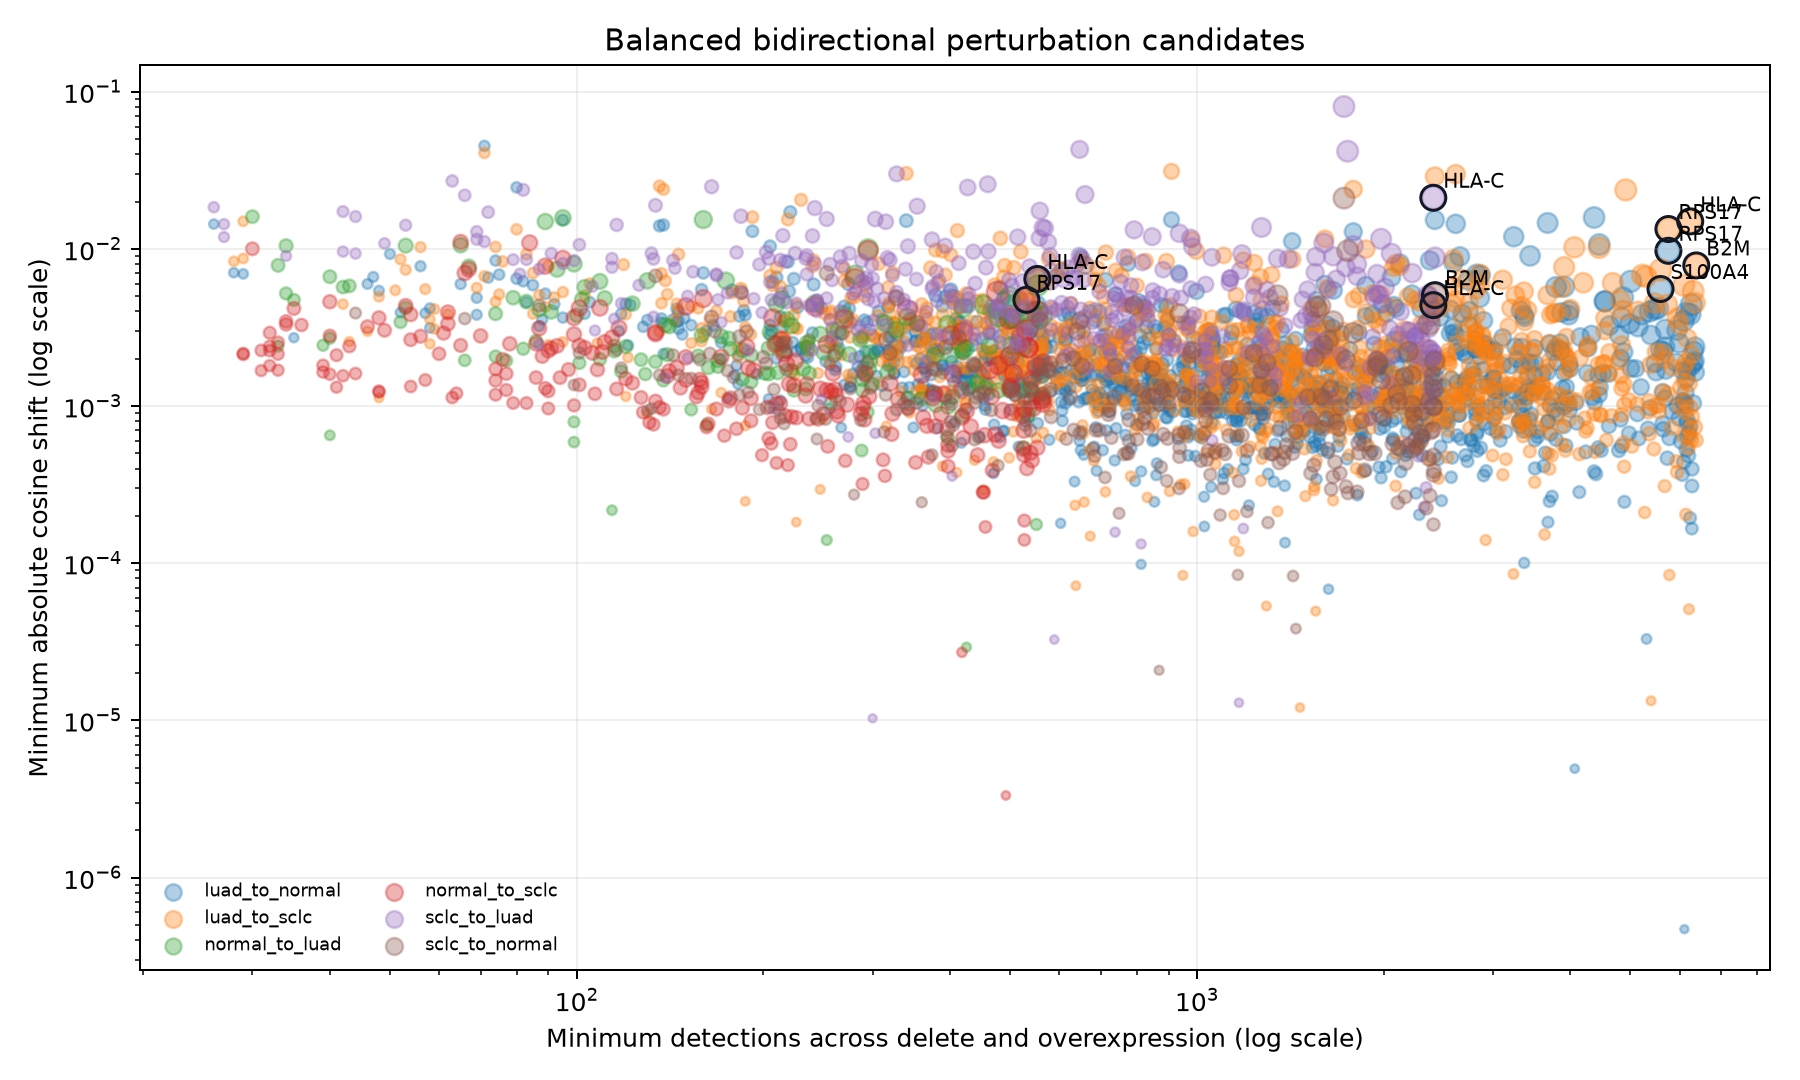

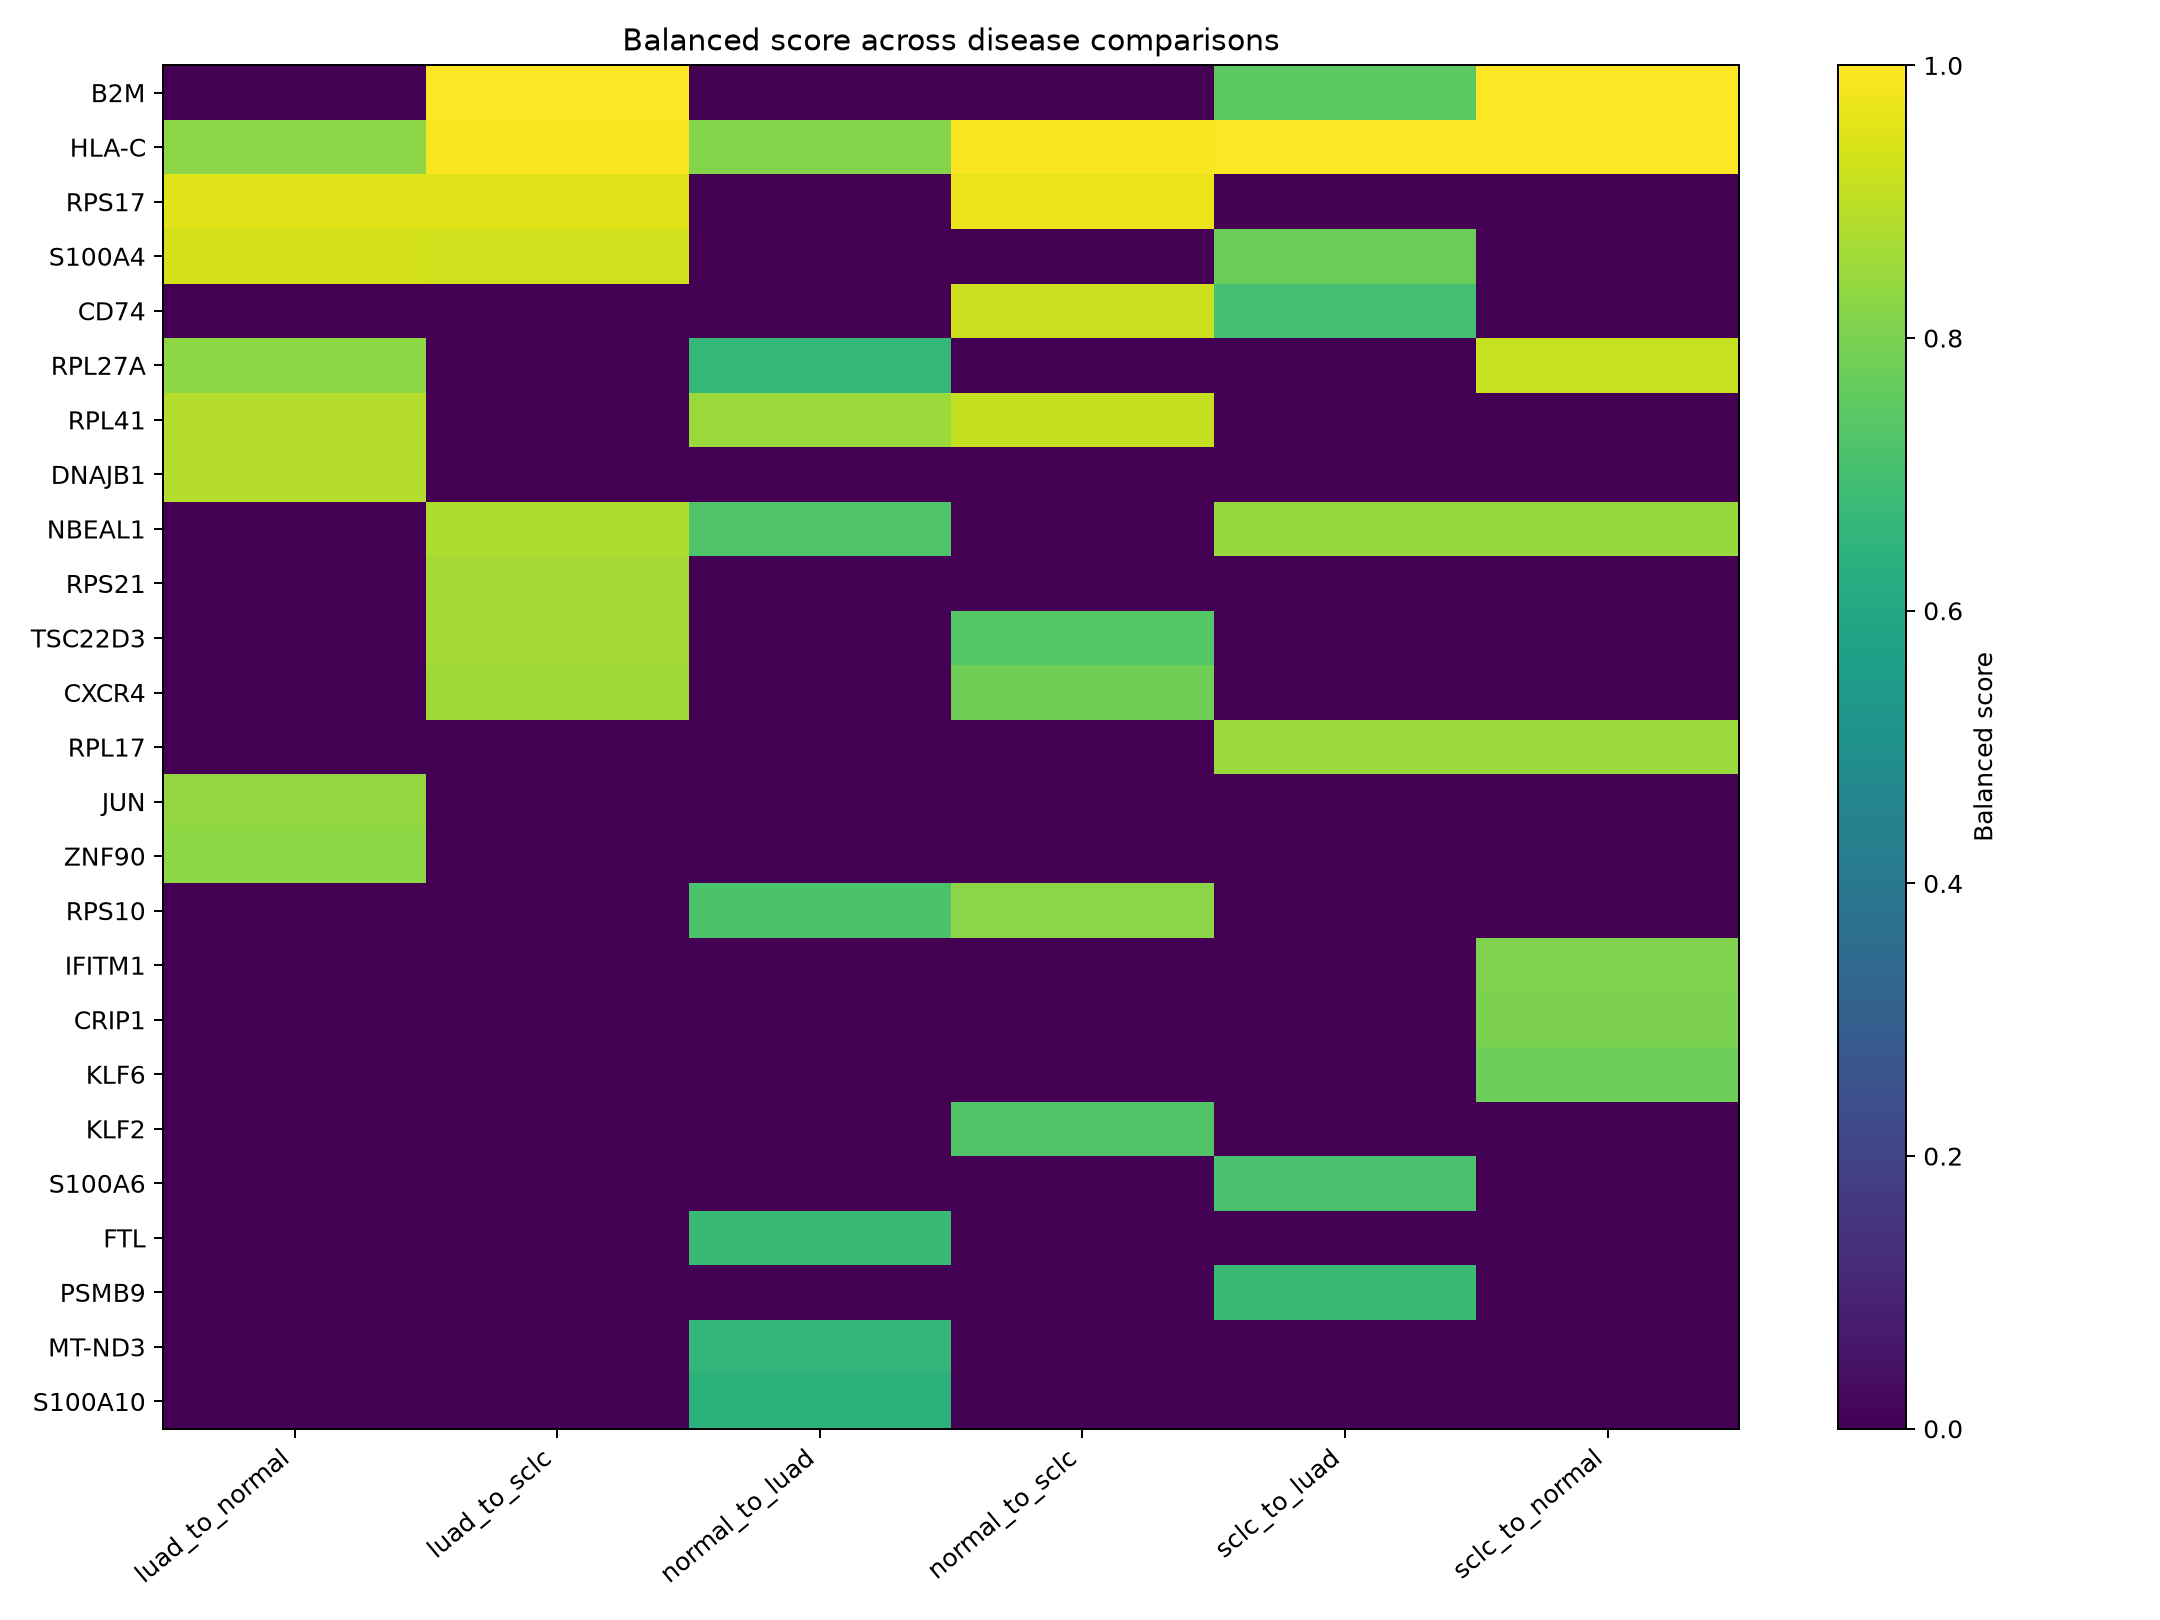

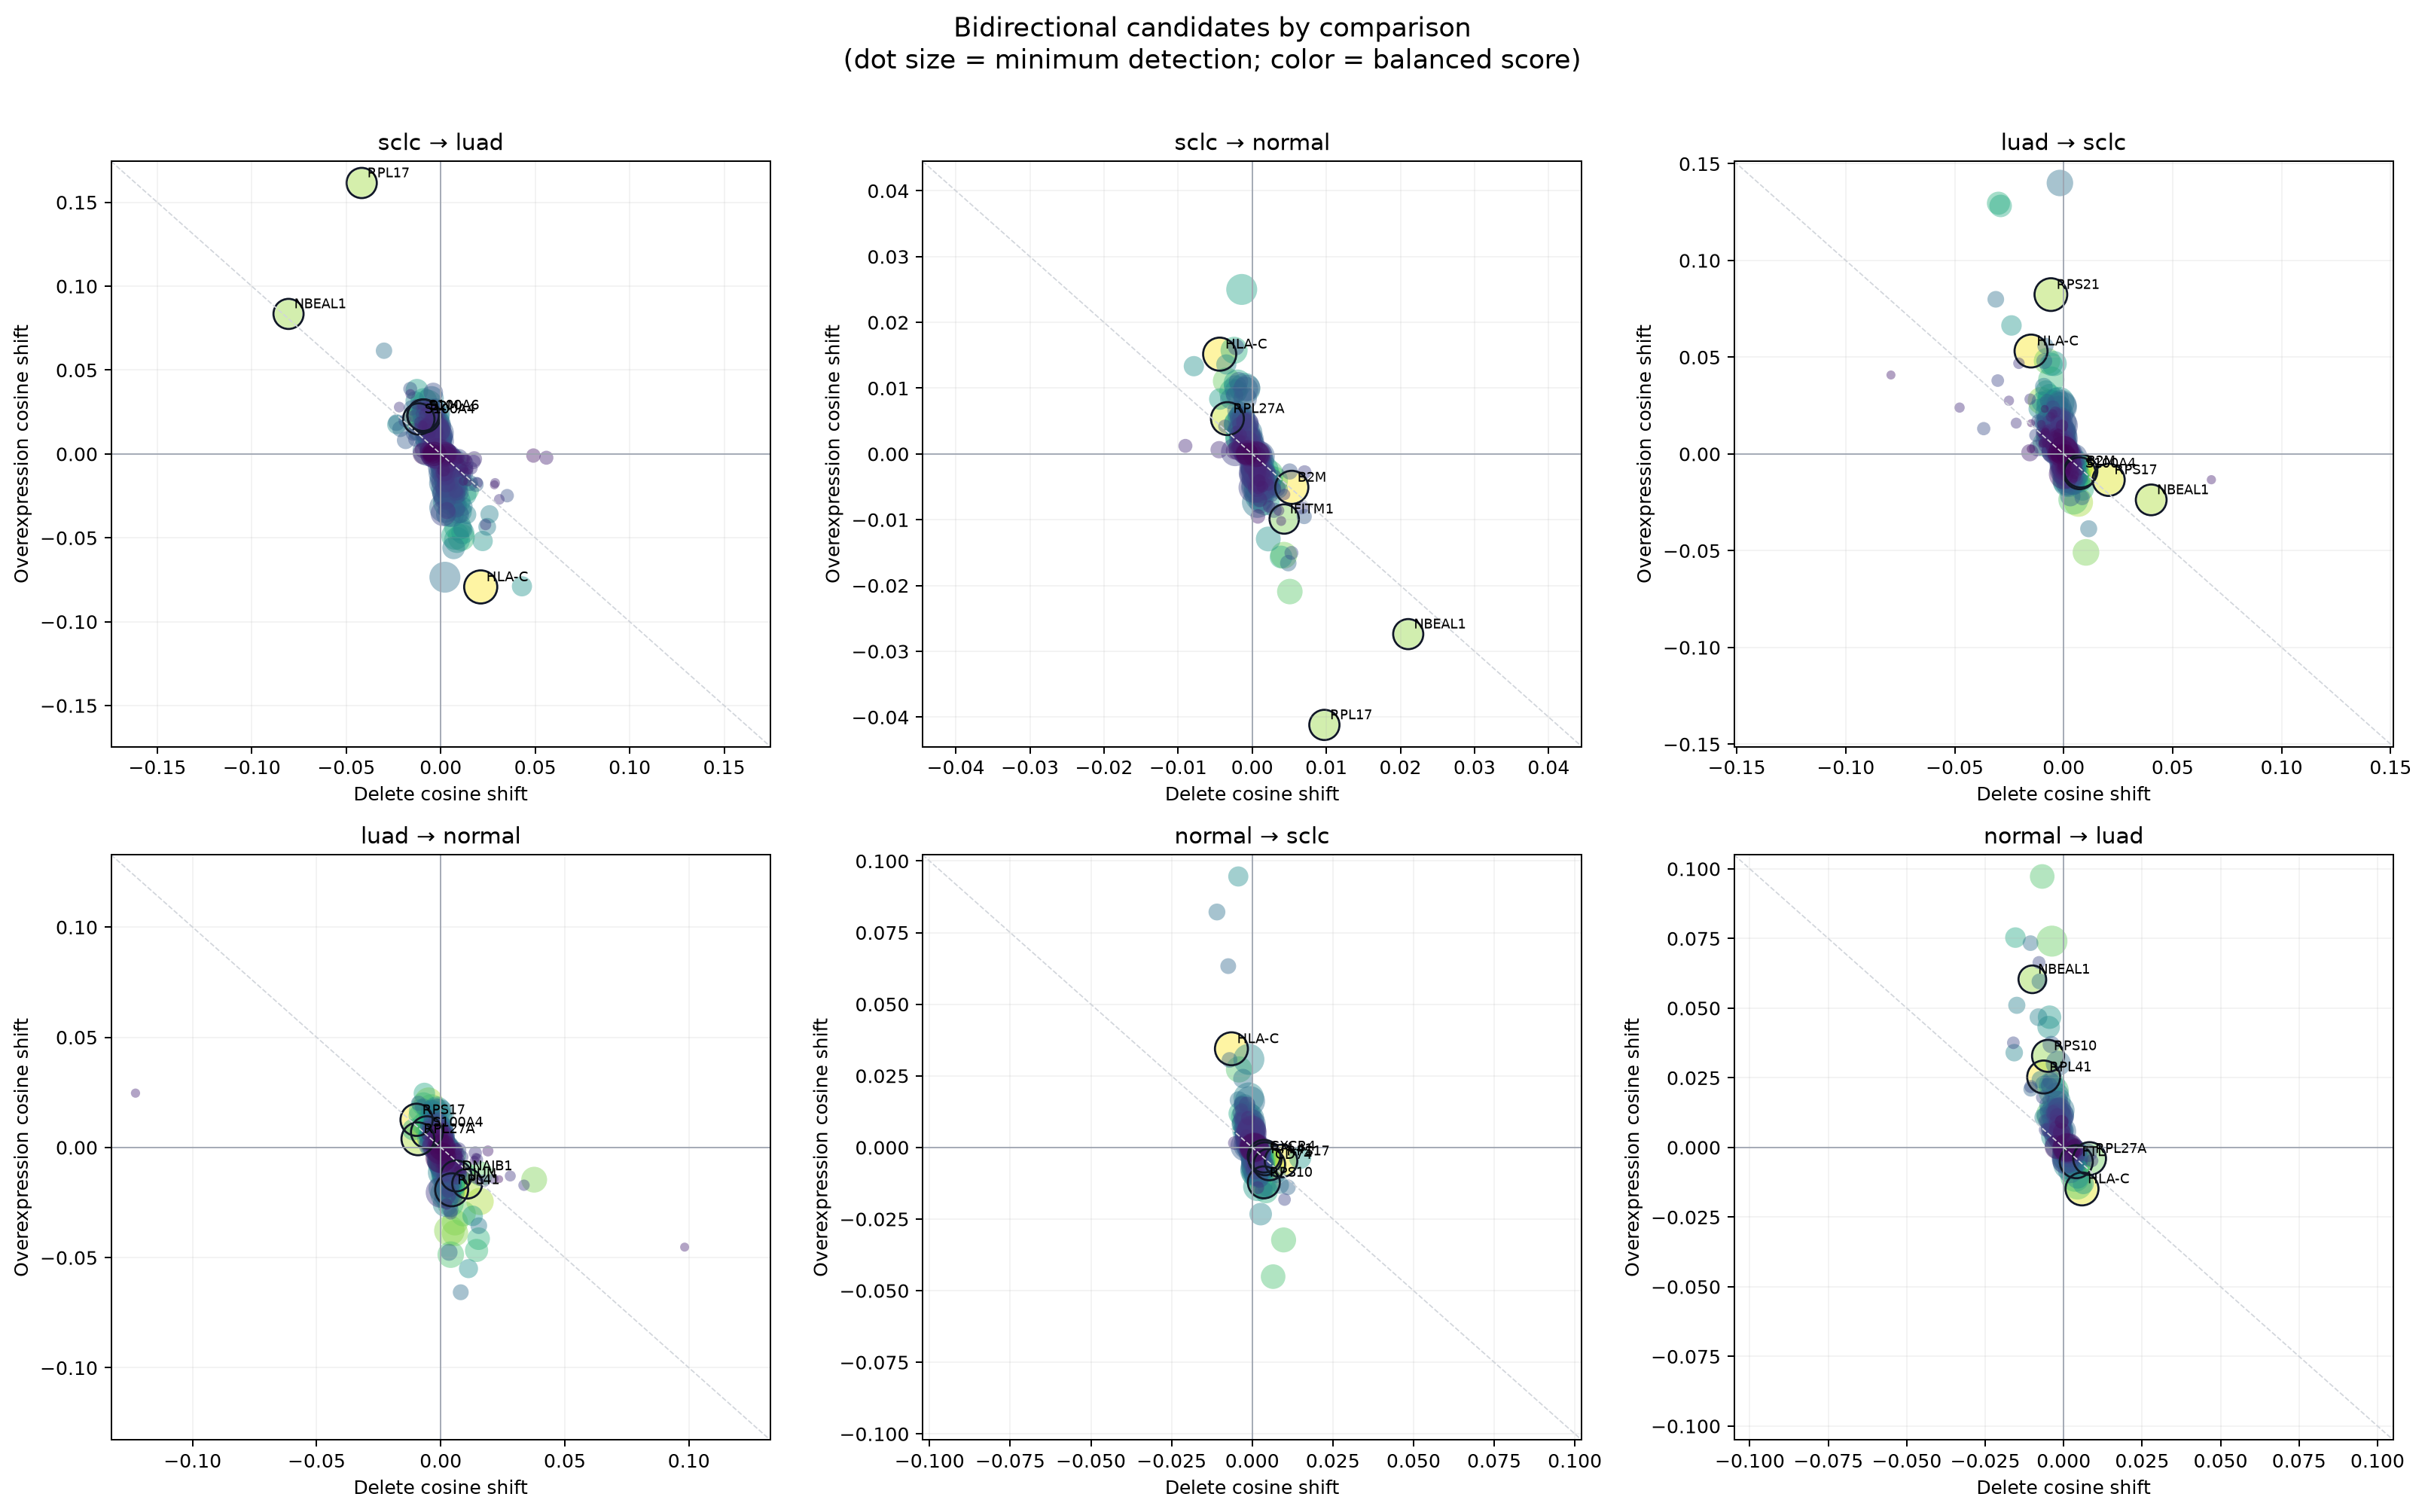

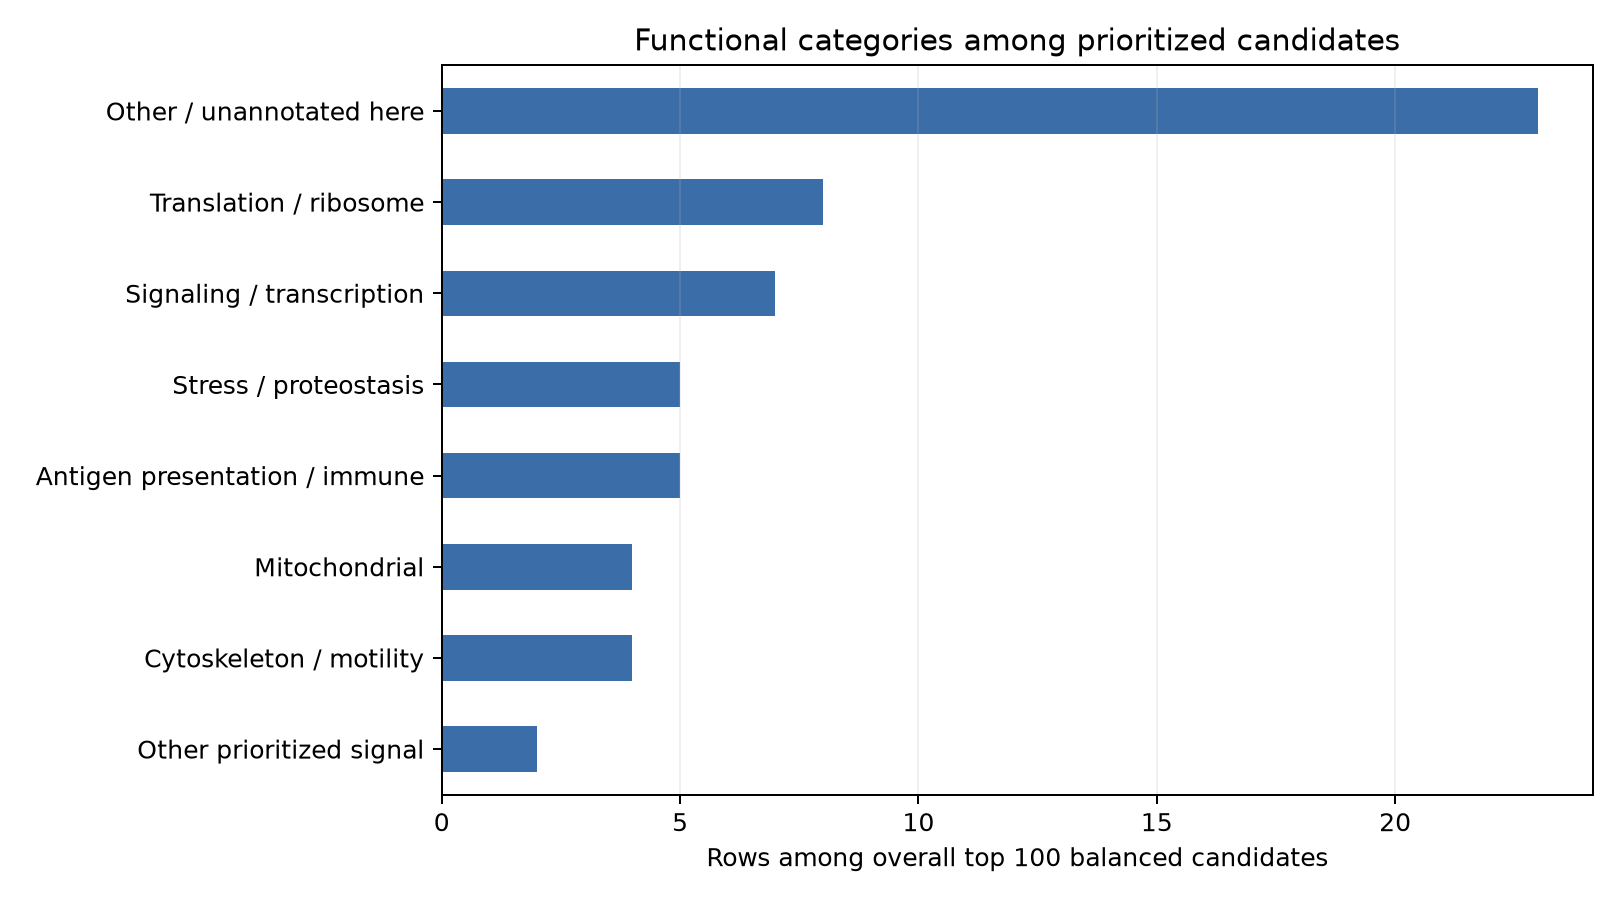

In [4]:
display(Image(filename=str(FIGURES / 'balanced_detection_shift_scatter.png')))
display(Image(filename=str(FIGURES / 'balanced_score_heatmap.png')))
display(Image(filename=str(FIGURES / 'bidirectional_candidates_by_comparison.png')))
display(Image(filename=str(FIGURES / 'functional_categories.png')))

## Candidates by comparison

Each row below is one of the top 15 balanced candidates for its disease transition. In the six-panel figure, marker size is the minimum detection count across deletion and overexpression.

In [5]:
top_by_comparison[['comparison', 'Gene_name', 'delete_shift', 'overexpress_shift', 'min_detection', 'balanced_score', 'functional_category']]

,comparison,Gene_name,delete_shift,overexpress_shift,min_detection,balanced_score,functional_category
0,luad_to_normal,RPS17,-0.009730,0.012540,5757,0.951339,Translation / ribosome
1,luad_to_normal,S100A4,-0.005558,0.006906,5590,0.937439,Cytoskeleton / motility
2,luad_to_normal,RPL41,0.004414,-0.019213,6269,0.888903,Translation / ribosome
3,luad_to_normal,DNAJB1,0.006218,-0.012939,5004,0.886943,Stress / proteostasis
4,luad_to_normal,JUN,0.010666,-0.016404,4453,0.836688,Signaling / transcription
...,...,...,...,...,...,...,...
85,sclc_to_normal,CYBA,0.002225,-0.003166,2192,0.718244,Other / unannotated here
86,sclc_to_normal,RPL41,0.001930,-0.003819,2418,0.702491,Translation / ribosome
87,sclc_to_normal,JUNB,-0.002618,0.009404,1629,0.671550,Signaling / transcription
88,sclc_to_normal,PSMB9,-0.002444,0.015757,1602,0.643468,Other / unannotated here


## Gene functionality

Functional labels are transparent, coarse categories for exploration. They are based on curated symbol sets and naming patterns in this notebook; they are not a replacement for GO/Reactome enrichment or literature review. The epithelial/ambient-RNA category is intentionally flagged as a contamination-sensitive interpretation.

In [6]:
functional_summary

,functional_category,genes,comparison_rows,median_score,median_min_detection
0,Other / unannotated here,23,27,0.677488,3981.0
1,Translation / ribosome,8,20,0.839966,1750.0
2,Signaling / transcription,7,12,0.777517,4324.5
3,Antigen presentation / immune,5,15,0.843302,2420.0
4,Stress / proteostasis,5,7,0.746618,3445.0
5,Cytoskeleton / motility,4,8,0.789876,5470.0
6,Mitochondrial,4,4,0.715479,5071.5
7,Other prioritized signal,2,7,0.783917,1726.0


In [7]:
FUNCTIONAL_LABELS = {
    'B2M': 'Antigen presentation / immune', 'HLA-C': 'Antigen presentation / immune',
    'CD74': 'Antigen presentation / immune', 'JUN': 'Signaling / transcription',
    'KLF6': 'Signaling / transcription', 'MAP2K2': 'Signaling / transcription',
    'CXCR4': 'Signaling / transcription', 'S100A4': 'Cytoskeleton / motility',
    'VIM': 'Cytoskeleton / motility', 'CD81': 'Cytoskeleton / motility',
    'HSPA1A': 'Stress / proteostasis', 'HSPA1B': 'Stress / proteostasis',
    'DNAJB1': 'Stress / proteostasis', 'NBEAL1': 'Other prioritized signal',
}
def gene_lookup(gene):
    cols = ['comparison', 'Gene_name', 'delete_shift', 'overexpress_shift', 'min_detection', 'balanced_score', 'functional_category']
    return rankings[rankings.Gene_name.eq(gene)].sort_values('balanced_score', ascending=False)[cols]

gene_lookup('HLA-C')

,comparison,Gene_name,delete_shift,overexpress_shift,min_detection,balanced_score,functional_category
2889,sclc_to_luad,HLA-C,0.021159,-0.079266,2405,0.996896,Antigen presentation / immune
3303,sclc_to_normal,HLA-C,-0.004390,0.015168,2405,0.996896,Antigen presentation / immune
2637,normal_to_sclc,HLA-C,-0.006439,0.034442,553,0.989324,Antigen presentation / immune
1244,luad_to_sclc,HLA-C,-0.014972,0.053189,6242,0.988816,Antigen presentation / immune
7,luad_to_normal,HLA-C,0.003842,-0.019057,6242,0.827510,Antigen presentation / immune
2483,normal_to_luad,HLA-C,0.005839,-0.014886,553,0.814895,Antigen presentation / immune


## Takeaways and caveats

- Prefer candidates that recur across comparisons with high `min_detection` and a substantial `min_abs_shift`.
- `HLA-C`, `B2M`, `NBEAL1`, `S100A4`, `CXCR4`, `JUN`, and `MAP2K2` are useful starting points for review.
- Ribosomal, mitochondrial, heat-shock, and housekeeping genes can be statistically strong but may reflect global cell state or technical effects.
- Epithelial markers require ambient-RNA, doublet, and epithelial-burden sensitivity checks.
- Donor-stratified stability and independent biological validation are required before causal interpretation.